2. Importação das bibliotecas

In [3]:
%pip install -q numpy pandas seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
%pip freeze > requeriments.txt

Note: you may need to restart the kernel to use updated packages.


In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
np.random.seed(42)

3. Script para geração de dados

In [14]:
num_usuarios = 500

In [15]:
visitas = np.random.randint(1, 51, size = num_usuarios)

In [16]:
# tempo no site com média de 20 min, desvio padrão de 5, com um bônus por visita
tempo_no_site = np.random.normal(loc = 20, scale = 5, size = num_usuarios) + (visitas * 0.5)
tempo_no_site = np.round(tempo_no_site, 2) # apenas para arredondar

In [17]:
itens_no_carrinho = np.random.randint(0, 8, size=num_usuarios) + (visitas // 10)
itens_no_carrinho = (itens_no_carrinho + (tempo_no_site // 15)).astype(int)

In [18]:
valor_compra = (itens_no_carrinho * 35) + np.random.normal(loc = 0, scale=10, size=num_usuarios)

valor_compra[itens_no_carrinho == 0] = 0
valor_compra[valor_compra < 0] = 0
valor_compra = np.round(valor_compra, 2)

In [19]:
dados_ecommerce = np.column_stack((visitas, tempo_no_site, itens_no_carrinho, valor_compra))

In [21]:
print(dados_ecommerce.shape)
print(dados_ecommerce[:5])

(500, 4)
[[ 39.    23.29   9.   314.54]
 [ 29.    29.38   5.   177.43]
 [ 15.    26.24   6.   207.59]
 [ 43.    35.26   8.   283.52]
 [  8.    32.16   3.    92.48]]


4. Análise Estatística Descritiva


Média de Visitas: 25.86
Média de Tempo no Site: 32.78
Média de Itens no Carrinho: 7.20
Média de Valor de Compra (Ticket médio): R$ 252.70

Mediana de Valor de Compra: R$ 248.13
Desvio Padrão do Valor da Compra: R$ 106.94

Maior valor de compra: R$ 530.37
Menor valor de compra (de quem comprou): R$ 23.42


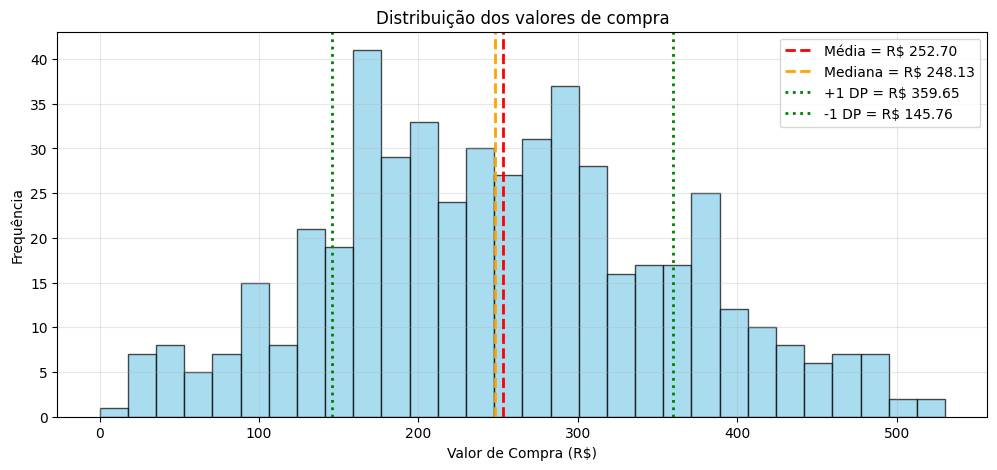

In [25]:
visitas_col = dados_ecommerce[:,0]
tempo_col = dados_ecommerce[:,1]
itens_col = dados_ecommerce[:,2]
valor_col = dados_ecommerce[:,3]


media_visitas = np.mean(visitas_col)
media_tempo = np.mean(tempo_col)
media_itens = np.mean(itens_col)
media_valor = np.mean(valor_col)

print(f'\nMédia de Visitas: {media_visitas:.2f}\nMédia de Tempo no Site: {media_tempo:.2f}\nMédia de Itens no Carrinho: {media_itens:.2f}\nMédia de Valor de Compra (Ticket médio): R$ {media_valor:.2f}')

mediana_valor = np.median(valor_col)
print(f'\nMediana de Valor de Compra: R$ {mediana_valor:.2f}')

std_valor = np.std(valor_col) #desvio padrão
print(f'Desvio Padrão do Valor da Compra: R$ {std_valor:.2f}')

max_valor = np.max(valor_col)
min_valor_positivo = np.min(valor_col[valor_col > 0])
print(f'\nMaior valor de compra: R$ {max_valor:.2f}\nMenor valor de compra (de quem comprou): R$ {min_valor_positivo:.2f}')


# Plotando um gráfico
plt.figure(figsize=(12, 5))
plt.hist(valor_col, bins=30, color = 'skyblue', edgecolor='black', alpha = 0.7)
plt.axvline(media_valor, color='red', linestyle = '--', linewidth=2, label=f'Média = R$ {media_valor:.2f}')
plt.axvline(mediana_valor, color='orange', linestyle='--', linewidth = 2, label=f'Mediana = R$ {mediana_valor:.2f}')
plt.axvline(media_valor + std_valor, color='green', linestyle = ':', linewidth=2, label=f'+1 DP = R$ {media_valor + std_valor:.2f}')
plt.axvline(media_valor - std_valor, color='green', linestyle = ':', linewidth=2, label=f'-1 DP = R$ {media_valor - std_valor:.2f}')
plt.title('Distribuição dos valores de compra')
plt.xlabel('Valor de Compra (R$)')
plt.ylabel('Frequência')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

5. Segmentação e Análise de Clientes

In [ ]:
clientes_alto_valor = dados_ecommerce[dados_ecommerce[:, 3] > 250]
print(f'Número de clientes alto valor (gasto > R$250): {clientes_alto_valor.shape[0]}')

media_visitas_alto_valor = np.mean(clientes_alto_valor[:, 0])
media_tempo_alto_valor = np.mean(clientes_alto_valor[:, 1])
print(f'Média visitas clientes alto valor: {media_visitas_alto_valor:.2f}\n')
print(f'Média tempo clientes alto valor: {media_tempo_alto_valor:.2f}\n')

Número de clientes alto valor (gasto > R$250): 245
Média visitas clientes alto valor: 33.29

Média tempo clientes alto valor: 37.11



In [32]:
visitas_sem_compra = dados_ecommerce[dados_ecommerce[:, 3] == 0]
print(f'Número de visitantes que não compraram: {visitas_sem_compra.shape[0]}')

media_tempo_sem_compra = np.mean(visitas_sem_compra[:, 0])
media_visita_sem_compra = np.mean(visitas_sem_compra[:, 1])
print(f'Média de visitas desses visitantes: {media_tempo_sem_compra:.2f}')
print(f'Média tempo no site: {media_visita_sem_compra:.2f} min\n')

Número de visitantes que não compraram: 1
Média de visitas desses visitantes: 7.00
Média tempo no site: 14.71 min



5. Análise de Correlação

Matriz de Correlação
[[1.   0.83 0.65 0.65]
 [0.83 1.   0.6  0.59]
 [0.65 0.6  1.   1.  ]
 [0.65 0.59 1.   1.  ]]


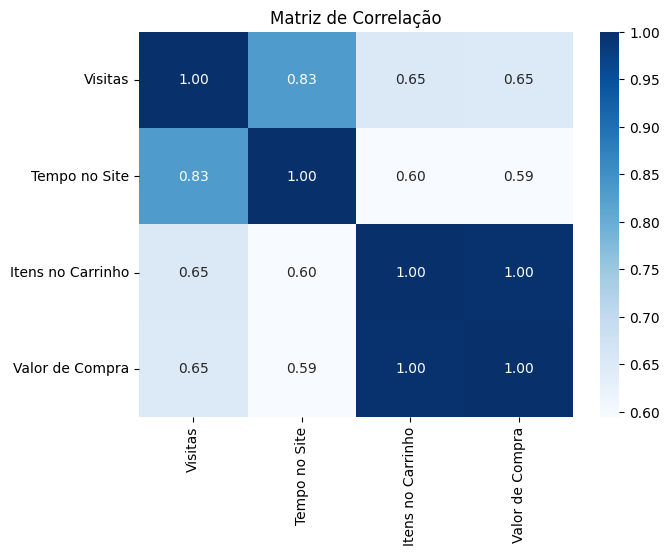

In [34]:
matriz_correlacao = np.corrcoef(dados_ecommerce, rowvar=False)

print('Matriz de Correlação')
print(np.round(matriz_correlacao,2))

#plotar gráfico
nomes_variaveis = ['Visitas', 'Tempo no Site', 'Itens no Carrinho', 'Valor de Compra']

df_correlacao = pd.DataFrame(
    matriz_correlacao,
    index=nomes_variaveis,
    columns=nomes_variaveis
)

plt.figure(figsize=(7,5))
sns.heatmap(df_correlacao, annot=True, cmap='Blues', fmt ='.2f')
plt.title('Matriz de Correlação')
plt.show()